# 01 — Data Understanding

**Goal of this notebook:** understand the cinnamon export sales data *before*
changing anything. We observe and record; we do **not** clean here. Cleaning
happens in `02_preprocessing_eda`.

What we produce:
1. Shape, dtypes, and a quick look at the rows.
2. Missing-value and cardinality reports.
3. Numeric summary (with negative / zero / outlier flags).
4. Categorical field inspection.
5. The **product-volume Pareto curve** — the single most important chart, it
   justifies the tier-based modelling strategy.
6. Order Date vs Invoice Date consistency check, and the decision of which date
   defines a "week".

All heavy lifting lives in `src/` so the notebook stays readable and the same
functions can be reused in later steps and the report.

In [1]:
# Make the project's src package importable when running from notebooks/
import sys
from pathlib import Path

# project root = parent of the notebooks/ folder
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loader, profiling

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
config.ensure_dirs()
print("Project root:", config.PROJECT_ROOT)
print("Raw file exists:", config.RAW_FILE.exists())

Project root: /home/claude/cinnamon_sales_forecasting
Raw file exists: True


## 1. Load & first look

`load_raw()` reads the xlsx and applies *light* coercion only: dates -> datetime, sales fields -> numeric, and it derives `Product9` (first 9 chars of Product Code). Nothing is dropped or fixed.

In [2]:
df = data_loader.load_raw()
print("Shape:", df.shape)
df.head()

Shape: (60670, 15)


,Region,Country,Customer Code,Customer ID,Brand Category,Product Range,Sales Channel,Product Code,Order Date,Invoice Date,Invoice No,Sales USD,Sales Qty,Sales KG,Product9
0,EUROPE,POLAND,34592,5BX,RETAIL,PREMIUM GRADE,RETAIL,44737-053-R09-SQW-WWJ-0334ST-4.4G-PRM,2022-04-01,2022-04-02,INV/34942603,22551.0,4122.0,2943.0,44737-053
1,EUROPE,POLAND,34592,5BX,RETAIL,PREMIUM GRADE,RETAIL,44737-053-R09-SQW-WWJ-0334ST-4.4G-PRM,2022-05-18,2022-05-19,INV/23356886,14446.0,2551.0,1905.0,44737-053
2,EUROPE,POLAND,34592,5BX,RETAIL,PREMIUM GRADE,RETAIL,44737-053-R09-SQW-WWJ-0334ST-4.4G-PRM,2022-05-30,2022-05-31,INV/56913810,18650.0,3335.0,2409.0,44737-053
3,EUROPE,POLAND,34592,5BX,RETAIL,PREMIUM GRADE,RETAIL,44737-053-R09-SQW-WWJ-0334ST-4.4G-PRM,2022-07-15,2022-07-14,INV/52868828,22857.0,4202.0,3000.0,44737-053
4,EUROPE,POLAND,34592,5BX,RETAIL,PREMIUM GRADE,RETAIL,44737-053-R09-SQW-WWJ-0334ST-4.4G-PRM,2022-09-29,2022-10-03,INV/49958838,12716.0,2403.0,1710.0,44737-053


In [3]:
df.dtypes

Region                       str
Country                      str
Customer Code             string
Customer ID                  str
Brand Category               str
Product Range                str
Sales Channel                str
Product Code                 str
Order Date        datetime64[us]
Invoice Date      datetime64[us]
Invoice No                   str
Sales USD                float64
Sales Qty                float64
Sales KG                 float64
Product9                  string
dtype: object

## 2. Missing values

How much is missing, and where. We only *record* this now; the fix is decided in step 2.

In [4]:
profiling.missing_report(df)

,missing,missing_pct,dtype
Order Date,142,0.234,datetime64[us]
Product Range,3,0.005,str
Country,3,0.005,str
Sales Channel,3,0.005,str
Brand Category,3,0.005,str
Invoice Date,3,0.005,datetime64[us]
Sales Qty,2,0.003,float64
Sales KG,2,0.003,float64
Sales USD,2,0.003,float64
Region,1,0.002,str


## 3. Cardinality

Unique values per column. Note the two product keys: the full `Product Code` vs the 9-char `Product9` we forecast on.

In [5]:
profiling.cardinality_report(df)

,n_unique,dtype
Product Code,13734,str
Product9,13725,string
Sales USD,11923,float64
Invoice No,4709,str
Sales KG,3342,float64
Sales Qty,2903,float64
Invoice Date,855,datetime64[us]
Order Date,833,datetime64[us]
Customer Code,191,string
Customer ID,191,str


## 4. Numeric summary — quantities, returns, outliers

`Sales Qty` is the **target**. Watch three things the cleaning step must handle:
* **negatives** = returns / credit notes,
* **zeros** = no-op lines,
* the enormous **max** vs the median — almost certainly a unit / data-entry error.

In [6]:
profiling.numeric_summary(df)

,count,mean,std,min,25%,50%,75%,max,n_negative,n_zero,n_missing
Sales USD,60668.0,7287.004352,902953.642606,-62049.0,325.0,949.0,2721.0,222396655.0,103,6724,2
Sales Qty,60668.0,461.234374,57311.025363,-1513.0,15.0,50.0,149.0,14115419.0,140,38,2
Sales KG,60668.0,574.927771,71605.283930,-11887.0,7.0,30.0,109.0,17635059.0,110,6701,2


In [7]:
# Inspect the most extreme Sales Qty rows -- candidate outliers to investigate
df.nlargest(5, config.COL_SALES_QTY)[
    [config.COL_PRODUCT9, config.COL_COUNTRY, config.COL_ORDER_DATE,
     config.COL_SALES_QTY, config.COL_SALES_KG, config.COL_SALES_USD]
]

,Product9,Country,Order Date,Sales Qty,Sales KG,Sales USD
60667,43962-015,NaN,NaT,14115419.0,17635059.0,222396655.0
273,41186-085,AUSTRALIA,2025-04-10,13524.0,20224.0,136789.0
242,53064-028,AUSTRALIA,2024-08-22,13046.0,20109.0,148930.0
203,53064-028,AUSTRALIA,2023-02-15,12758.0,19332.0,150191.0
271,41186-085,AUSTRALIA,2025-03-28,11873.0,17588.0,128327.0


## 5. Categorical fields

The segments demand flows through. Note minor dirtiness (e.g. double spaces in some Brand Category labels) to normalise later.

In [8]:
for col in [config.COL_CHANNEL, config.COL_REGION,
            config.COL_BRAND, config.COL_RANGE]:
    print(f"\n=== {col} (top values) ===")
    display(profiling.category_value_counts(df, col, top=15))


=== Sales Channel (top values) ===


,count,pct
Sales Channel,,
FOOD SERVICE,33211,54.74
RETAIL,25081,41.34
GLOBAL,2274,3.75
BULK,101,0.17
NaN,3,0.00



=== Region (top values) ===


,count,pct
Region,,
ASIA,19454,32.07
EUROPE,14444,23.81
OCEANIA,9692,15.97
MIDDLE EAST,8142,13.42
CIS,3087,5.09
AFRICA,2480,4.09
SOUTH AMERICA,2022,3.33
NORTH AMERICA,1069,1.76
WEST INDIES,162,0.27



=== Brand Category (top values) ===


,count,pct
Brand Category,,
FOOD SERVICE,27710,45.67
RETAIL,23478,38.70
PROMOTIONAL,6613,10.90
DEDICATED PRODUCTS,913,1.50
SPECIALITY & GIFT,769,1.27
PRIVATE LABEL RETAIL,641,1.06
SPICE,175,0.29
BULK,111,0.18
LOCAL MARKET,99,0.16



=== Product Range (top values) ===


,count,pct
Product Range,,
FUN GRADE,7211,11.89
R-SERIES GOURMET,7025,11.58
GREEN GRADE,6298,10.38
GOURMET GRADE,5828,9.61
PREMIUM GRADE,4857,8.01
EXCEPTIONAL GRADE,4756,7.84
SPECIALTY COMPOUNDS,3908,6.44
SILVER JUBILEE GOURMET,1976,3.26
WOODEN BOXES / PRESENTERS,1856,3.06


## 6. Product concentration — the Pareto curve

This is the headline finding. A tiny fraction of products carry almost all the
volume, while thousands have only one or two lifetime transactions. This is why
a single global model can't be applied uniformly: we will **tier** products and
route each tier to a suitable method.

In [9]:
headline = profiling.sparsity_headline(df)
for k, v in headline.items():
    print(f"{k:>28}: {v:,}" if isinstance(v, int) else f"{k:>28}: {v}")

              n_transactions: 60,670
                  n_products: 13,725
     median_txns_per_product: 2.0
         products_with_1_txn: 6,006
          products_le_3_txns: 9,228
         products_le_10_txns: 12,267
         products_ge_50_txns: 34
   products_for_80pct_volume: 172
   products_for_95pct_volume: 1,536


saved:

 /home/claude/cinnamon_sales_forecasting/outputs/figures/01_product_pareto.png


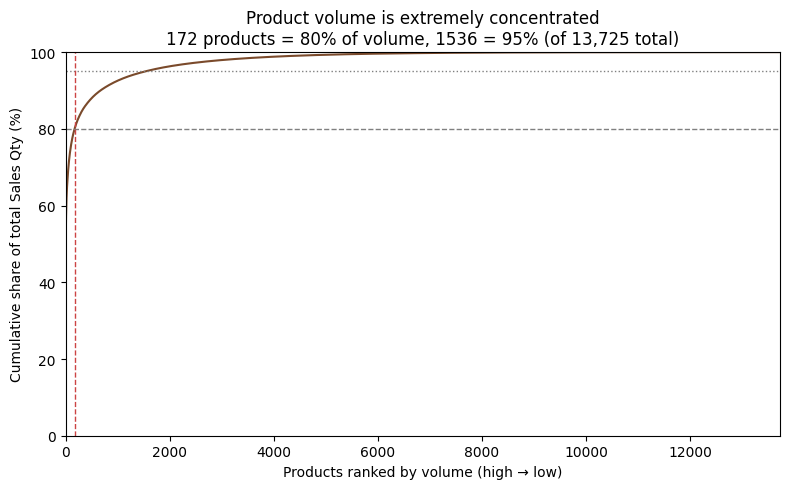

In [10]:
fig, ax, path = profiling.plot_pareto(df)
print("saved:", path)
plt.show()

saved: /home/claude/cinnamon_sales_forecasting/outputs/figures/01_txns_per_product.png


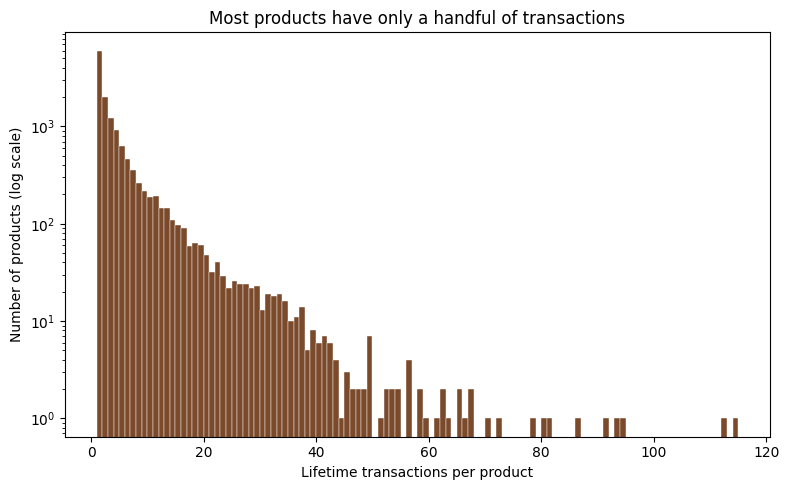

In [11]:
fig, ax, path = profiling.plot_txn_distribution(df)
print("saved:", path)
plt.show()

## 7. Time coverage & the date decision

We compare **Order Date** and **Invoice Date**. Order Date reflects when demand
occurred, so it is the better anchor for a *demand* forecast — Invoice Date
trails it. We also flag rows where the invoice predates the order (a data-quality
issue for step 2).

In [12]:
dates = profiling.date_consistency_report(df)
for k, v in dates.items():
    print(f"{k:>26}: {v}")
print(f"\nDecision: bucket demand into weeks using "
      f"'{config.DEMAND_DATE_COL}', anchored {config.WEEK_ANCHOR}.")

            order_date_min: 2022-02-28 00:00:00
            order_date_max: 2025-09-17 00:00:00
          invoice_date_min: 2022-04-01 00:00:00
          invoice_date_max: 2025-09-16 00:00:00
        order_date_missing: 142
      invoice_date_missing: 3
      invoice_before_order: 19028
   invoice_lag_days_median: 0.0
     invoice_lag_days_mean: 3.28

Decision: bucket demand into weeks using 'Order Date', anchored W-MON.


saved: /home/claude/cinnamon_sales_forecasting/outputs/figures/01_weekly_total_qty.png


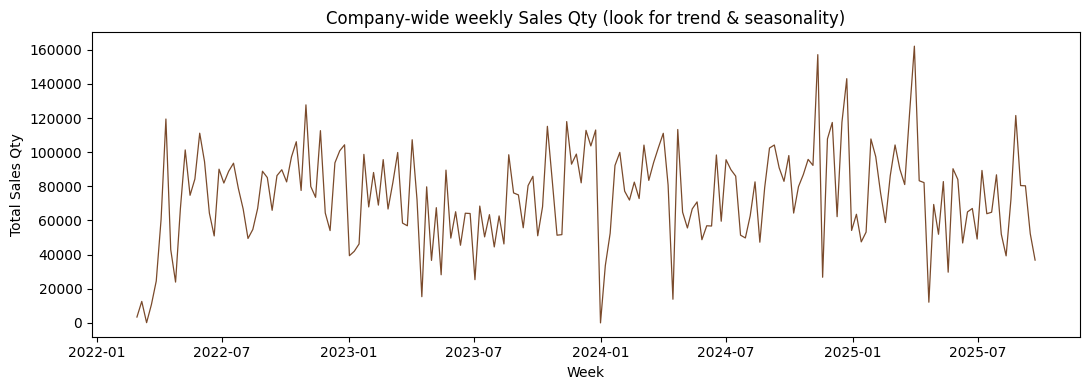

In [13]:
fig, ax, path = profiling.plot_weekly_total(df)
print("saved:", path)
plt.show()

## 8. Findings & hand-off to step 2

**What we learned**
* ~60.7k transactions, Feb 2022 → Sep 2025 (~185 weeks).
* Target `Sales Qty` is highly skewed; there are returns (negatives), zeros, and
  at least one implausible giant outlier.
* **Extreme product concentration**: ~170 products make 80% of volume; ~6,000
  products have a single transaction. → tier-based modelling.
* Small amounts of missing data across several columns; 142 missing Order Dates.
* Some rows have Invoice Date before Order Date — to flag in cleaning.

**Decisions carried forward**
* Product key = first 9 chars of Product Code (`Product9`).
* Week bucket = Order Date, Monday-anchored.
* Forecast horizon = 12 weeks.

**Next (step 2 — preprocessing):** handle missing dates, returns, and outliers;
aggregate to weekly series; reindex to fill zero-weeks; build the product tiers.